In [1]:
import os
print(os.getcwd())

c:\Users\jbusink1\OneDrive - HvA\Documenten\GitHub\Communicatie_Meetapparatuur


Totaal #bins: 500 (= 50 × 10)
Gemiddelde count per bin: 2.928 (theorie μ=3.000)


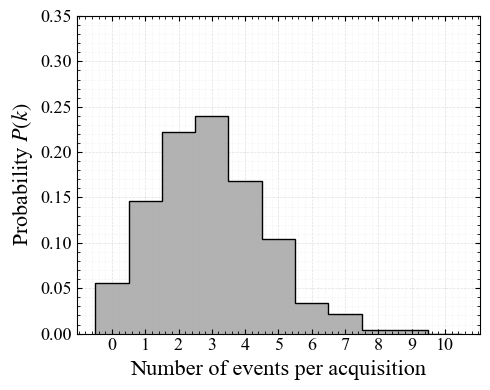

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial

# ----------------------------
# Instellingen
# ----------------------------
rng = np.random.default_rng(0)

lam = 15.0          # rate λ [events/s]
dt  = 0.2           # binlengte [s]
Tsub = 2.0         # duur per subsimulatie [s]
Nruns = 50         # aantal subsimulaties

mu = lam * dt       # Poisson-parameter per bin

# ---------- Font instellingen: Times New Roman ----------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------
# 1) Meerdere subsimulaties + poolen
# ----------------------------
all_counts = []

edges = np.arange(0.0, Tsub + dt, dt)

for _ in range(Nruns):
    # Poisson arrival times via exponentiële tussenpozen
    t = 0.0
    arrival_times = []
    while t < Tsub:
        t += rng.exponential(1.0 / lam)
        if t < Tsub:
            arrival_times.append(t)

    arrival_times = np.array(arrival_times)
    counts, _ = np.histogram(arrival_times, bins=edges)   # counts per bin voor deze run
    all_counts.append(counts)

# Stack / pool: alle bins van alle runs achter elkaar
all_counts = np.concatenate(all_counts)

print(f"Totaal #bins: {len(all_counts)} (= {Nruns} × {len(edges)-1})")
print(f"Gemiddelde count per bin: {all_counts.mean():.3f} (theorie μ={mu:.3f})")

# ----------------------------
# 2) Theorie (Poisson pmf)
# ----------------------------
kmax = max(10, int(all_counts.max()))
k_vals = np.arange(0, kmax + 1)
pmf = np.array([exp(-mu) * (mu**k) / factorial(k) for k in k_vals])

# ----------------------------
# 3) Plot (jouw stijl)
# ----------------------------
fig, ax = plt.subplots(figsize=(5, 4))

# Discrete bins: [-0.5, 0.5], [0.5, 1.5], ...
bins = np.arange(-0.5, kmax + 1.5, 1)

ax.hist(all_counts, bins=bins, density=True, histtype='stepfilled',color = 'black', alpha=0.3, lw=2)
ax.hist(all_counts, bins=bins, density=True, histtype='step',color = 'black', lw=1)

# Theorie erboven
# ax.plot(k_vals, pmf, 'o', ms=4)

ax.set_xlabel(r"Number of events per acquisition", fontsize=16)
ax.set_ylabel(r"Probability $P(k)$", fontsize=16)

ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.3)

ax.tick_params(axis='both', which='both', direction='in',
               top=True, right=True, labelsize=13)

ax.set_xticks(np.arange(0, kmax + 1, 1))
ax.minorticks_on()
ax.set_ylim(0,0.35)
plt.tight_layout()
plt.show()


In [ ]:
import pyvisa
rm = pyvisa.ResourceManager()
fg = rm.open_resource(rm.list_resources()[0])
dmm = rm.open_resource(rm.list_resources()[1])
print("Instrument gevonden:", fg.query("*IDN?"))
print("Instrument gevonden:", dmm.query("*IDN?"))

: 

In [ ]:
from instruments.hardware import open_instruments, close_instruments

